## Tahap Gathering
Dataset diambil dari Kaggle: [Studies Career Recommendation Dataset](https://www.kaggle.com/datasets/shanimmahir/studies-career-recommendation-dataset).
Dataset ini berisi nilai akademik siswa per mata pelajaran, partisipasi ekstrakurikuler,
dan aspirasi karier yang akan digunakan sebagai basis rekomendasi karier di SkillPath.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student-scores-6k.csv')  # sesuaikan nama filenya
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Social Network Studies,84,77,65,65,80,74,76


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          6000 non-null   int64
 1   first_name                  6000 non-null   str  
 2   last_name                   6000 non-null   str  
 3   email                       6000 non-null   str  
 4   gender                      6000 non-null   str  
 5   part_time_job               6000 non-null   bool 
 6   absence_days                6000 non-null   int64
 7   extracurricular_activities  6000 non-null   bool 
 8   weekly_self_study_hours     6000 non-null   int64
 9   career_aspiration           6000 non-null   str  
 10  math_score                  6000 non-null   int64
 11  history_score               6000 non-null   int64
 12  physics_score               6000 non-null   int64
 13  chemistry_score             6000 non-null   int64
 14  biology_score      

In [44]:
df.describe()

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.581500,81.277500,80.888000
std,1732.195139,2.628833,12.127581,13.222702,12.733923,12.537363,12.775765,13.719903,12.025082,11.635765
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.000000,50.000000,60.000000
25%,1500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.000000,72.000000,71.000000
50%,3000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.000000,83.000000,81.000000
75%,4500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.000000,91.000000,91.000000
max,6000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.000000,100.000000


In [45]:
df.shape

(6000, 17)

In [46]:
# Cek duplikat baris
df.duplicated().sum()

np.int64(0)

In [47]:
# Cek isi unik kolom kategorikal - siapa tau ada typo/inkonsistensi
df['career_aspiration'].unique()

<ArrowStringArray>
[                'Lawyer',                 'Doctor',     'Government Officer',
                 'Artist', 'Social Network Studies',      'Software Engineer',
                'Teacher',         'Business Owner',              'Scientist',
                 'Banker',                 'Writer',             'Accountant',
               'Designer',  'Construction Engineer',         'Game Developer',
         'Stock Investor',  'Real Estate Developer']
Length: 17, dtype: str

In [48]:
df['career_aspiration'].value_counts()

career_aspiration
Software Engineer         945
Business Owner            927
Social Network Studies    669
Banker                    507
Lawyer                    414
Accountant                378
Doctor                    357
Real Estate Developer     249
Stock Investor            219
Construction Engineer     204
Artist                    201
Game Developer            189
Government Officer        183
Teacher                   177
Designer                  168
Scientist                 117
Writer                     96
Name: count, dtype: int64

In [49]:
df['gender'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [50]:
# Double-check missing value per kolom (lebih detail dari info())
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [51]:
# Cek apakah ada kolom yang gak relevan buat analisis/model
df.columns.tolist()

['id',
 'first_name',
 'last_name',
 'email',
 'gender',
 'part_time_job',
 'absence_days',
 'extracurricular_activities',
 'weekly_self_study_hours',
 'career_aspiration',
 'math_score',
 'history_score',
 'physics_score',
 'chemistry_score',
 'biology_score',
 'english_score',
 'geography_score']

## Tahap Assessing
Hasil pengecekan menunjukkan tidak ada missing value maupun data duplikat pada dataset.
Seluruh kategori pada kolom `career_aspiration` dan `gender` sudah konsisten penulisannya.
Namun ditemukan ketidakseimbangan distribusi kelas pada `career_aspiration`
(contoh: Software Engineer 945 data vs Writer hanya 96 data), yang perlu diperhatikan
pada tahap pemodelan nanti.

## Tahap Cleaning
Kolom id, first_name, last_name, dan email dihapus karena bersifat identitas personal (PII)
dan tidak relevan untuk proses analisis maupun pemodelan rekomendasi karier.

In [52]:
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email'])
df_clean.head()

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,male,False,5,False,10,Social Network Studies,84,77,65,65,80,74,76


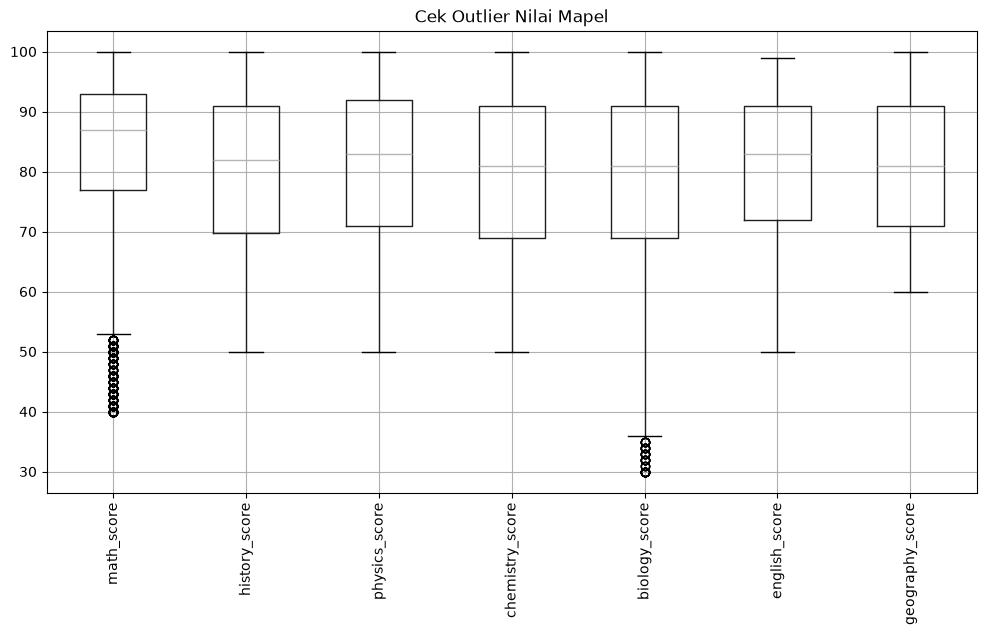

In [53]:
df_clean[['math_score','history_score','physics_score','chemistry_score',
          'biology_score','english_score','geography_score']].boxplot(figsize=(12,6), rot=90)
plt.title('Cek Outlier Nilai Mapel')
plt.show()

In [54]:
outlier_math = df_clean[df_clean['math_score'] < 55]
outlier_bio = df_clean[df_clean['biology_score'] < 55]
print("Jumlah outlier math_score:", len(outlier_math))
print("Jumlah outlier biology_score:", len(outlier_bio))

Jumlah outlier math_score: 249
Jumlah outlier biology_score: 192


In [55]:
df_clean['part_time_job'].unique()

array([False,  True])

In [56]:
df_clean['extracurricular_activities'].unique()

array([False,  True])

## Kesimpulan Cleaning
Ditemukan outlier pada math_score (249 data) dan biology_score (192 data), namun jumlah ini
tergolong wajar (~4% dari total data) dan nilainya masih dalam rentang valid (0-100).
Outlier ini tidak dihapus karena merepresentasikan variasi nilai siswa yang natural,
bukan indikasi kesalahan input data.

Kolom part_time_job dan extracurricular_activities juga sudah konsisten (boolean True/False),
sehingga tidak memerlukan proses cleaning tambahan.

## Tahap EDA - Distribusi Aspirasi Karier
Visualisasi berikut menunjukkan sebaran jumlah siswa berdasarkan aspirasi kariernya.

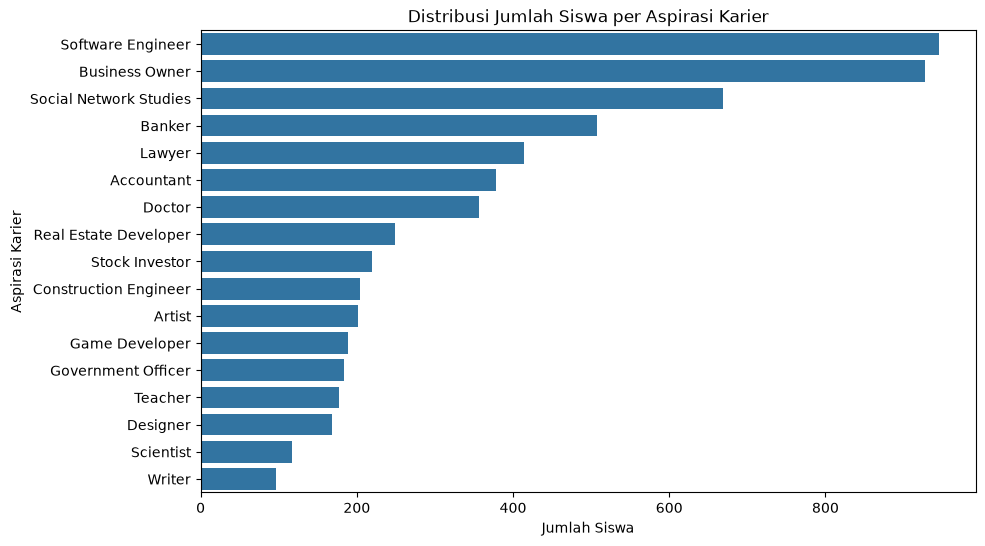

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, y='career_aspiration', order=df_clean['career_aspiration'].value_counts().index)
plt.title('Distribusi Jumlah Siswa per Aspirasi Karier')
plt.xlabel('Jumlah Siswa')
plt.ylabel('Aspirasi Karier')
plt.show()

Grafik di atas mengonfirmasi bahwa Software Engineer dan Business Owner adalah aspirasi karier
paling populer di kalangan siswa, sementara Writer dan Scientist adalah yang paling sedikit
diminati. Ketimpangan ini perlu diperhatikan pada tahap pemodelan nanti.

## Tahap EDA - Sebaran Nilai Biologi Berdasarkan Aspirasi Karier
Visualisasi berikut melihat apakah siswa dengan aspirasi karier tertentu (misal Doctor)
cenderung memiliki nilai Biologi yang lebih tinggi.

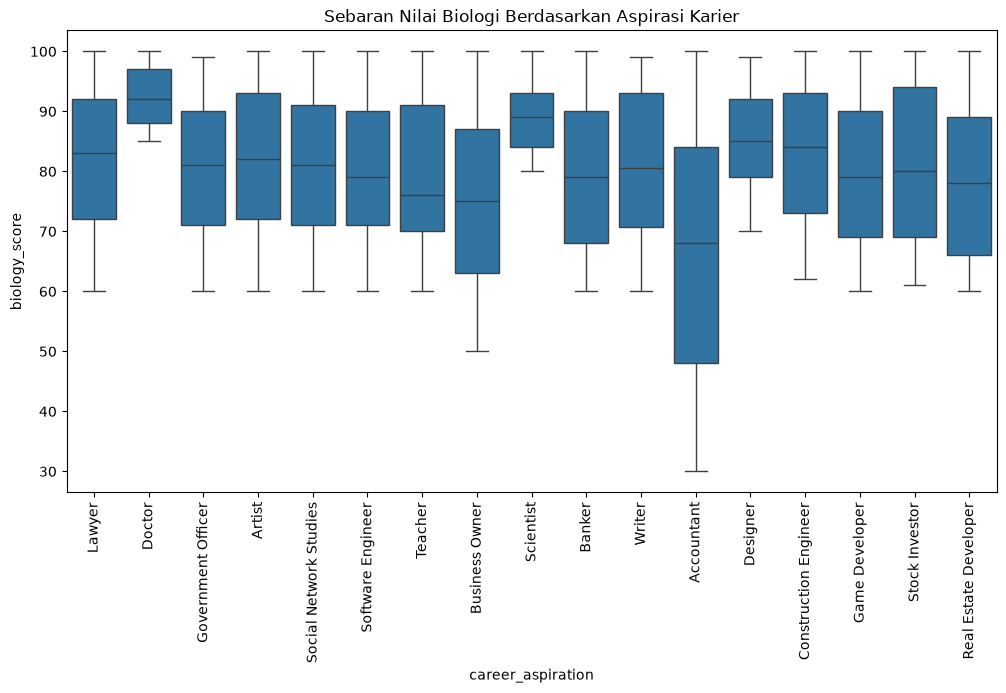

In [58]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='career_aspiration', y='biology_score')
plt.xticks(rotation=90)
plt.title('Sebaran Nilai Biologi Berdasarkan Aspirasi Karier')
plt.show()

Boxplot menunjukkan bahwa siswa dengan aspirasi karier Doctor dan Scientist cenderung
memiliki nilai Biologi yang lebih tinggi dan konsisten (median di atas 89), sedangkan
siswa dengan aspirasi Accountant dan Business Owner memiliki nilai Biologi yang lebih
rendah dan lebih bervariasi. Hal ini menunjukkan bahwa nilai akademik pada mapel tertentu
berkaitan dengan pilihan karier siswa, sehingga relevan digunakan sebagai salah satu fitur
dalam sistem rekomendasi karier.

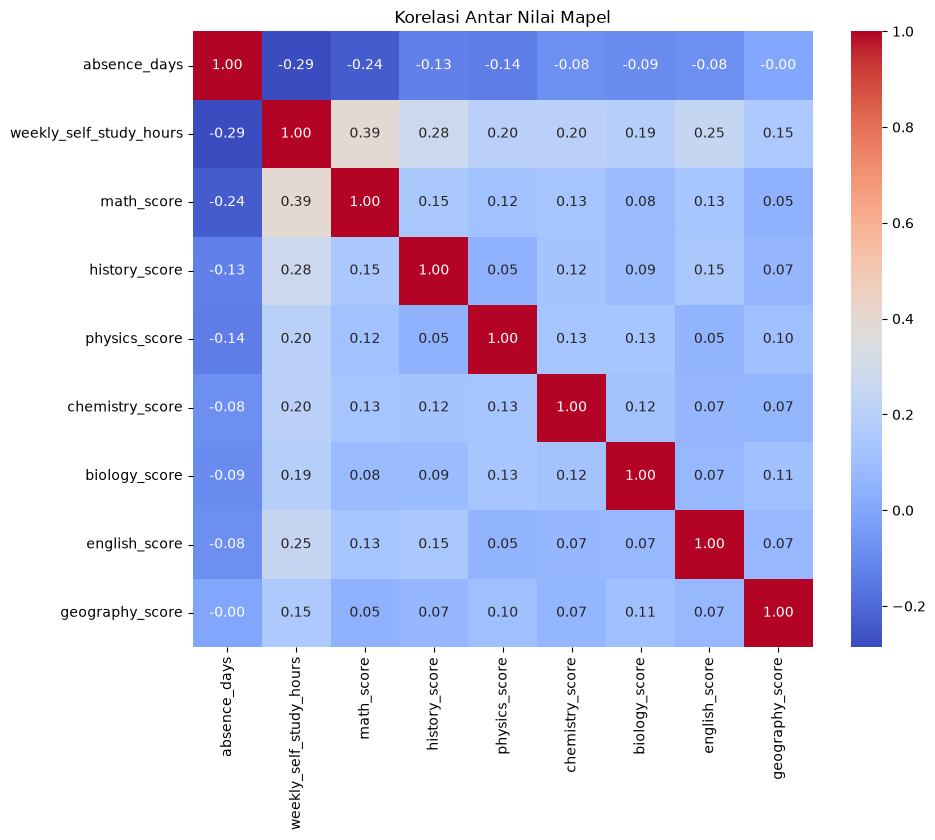

In [59]:
plt.figure(figsize=(10,8))
numeric_cols = df_clean.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Nilai Mapel')
plt.show()

Heatmap menunjukkan bahwa korelasi antar nilai mapel tergolong lemah (di bawah 0.4), yang berarti
setiap mapel memberikan sinyal yang relatif independen untuk membedakan karakteristik akademik siswa.
Korelasi tertinggi ditemukan antara weekly_self_study_hours dan math_score (0.39), menunjukkan bahwa
kebiasaan belajar mandiri berkontribusi terhadap nilai Matematika. Sebaliknya, absence_days berkorelasi
negatif dengan hampir seluruh nilai mapel, mengindikasikan bahwa tingkat kehadiran siswa berpengaruh
terhadap performa akademiknya secara umum.

## Modeling: Recommendation System

In [60]:
# ================================
# Recommendation System (Classification-based)
# ================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# --- 1. Pisahkan fitur (X) dan target (y) ---
# Sesuaikan nama kolom target dan kolom yang mau di-drop
target_col = 'career_aspiration'

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# --- 2. Encode fitur kategorikal (jika ada) ---
categorical_cols = X.select_dtypes(include='object').columns.tolist()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# --- 3. Encode target ---
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# --- 4. Split data train dan test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# --- 5. Scaling fitur numerik ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 6. Training model dengan class_weight balanced ---
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

# --- 7. Evaluasi model ---
y_pred = model.predict(X_test_scaled)
print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test, y_pred,
    target_names=target_encoder.classes_
))

# --- 8. Fungsi rekomendasi top-N karier ---
def recommend_career(student_data, top_n=3):
    """
    student_data: dict dengan key = nama kolom fitur, value = nilainya
    Contoh: {'math_score': 85, 'biology_score': 90, ...}
    """
    input_df = pd.DataFrame([student_data])

    # Encode kolom kategorikal input dengan encoder yang sama
    for col in categorical_cols:
        if col in input_df.columns:
            input_df[col] = encoders[col].transform(input_df[col])

    input_scaled = scaler.transform(input_df)

    proba = model.predict_proba(input_scaled)[0]
    top_indices = np.argsort(proba)[::-1][:top_n]

    recommendations = [
        (target_encoder.classes_[i], round(proba[i] * 100, 2))
        for i in top_indices
    ]
    return recommendations

# --- 9. Contoh penggunaan ---
sample_index = X_test.index[0]
sample_student = df_clean.loc[sample_index].drop(target_col).to_dict()
# ganti kembali kolom kategorikal ke bentuk aslinya kalau mau manual test
result = recommend_career(sample_student, top_n=3)
print("Rekomendasi karier:", result)

/var/folders/69/ymnylyz95_g4pk88t370klz00000gn/T/ipykernel_8244/1794163003.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


Akurasi: 0.975
                        precision    recall  f1-score   support

            Accountant       0.96      0.92      0.94        76
                Artist       1.00      1.00      1.00        40
                Banker       0.97      0.97      0.97       101
        Business Owner       0.97      1.00      0.98       185
 Construction Engineer       1.00      1.00      1.00        41
              Designer       1.00      0.91      0.95        34
                Doctor       0.96      1.00      0.98        71
        Game Developer       1.00      1.00      1.00        38
    Government Officer       0.92      0.92      0.92        37
                Lawyer       0.97      1.00      0.98        83
 Real Estate Developer       1.00      0.94      0.97        50
             Scientist       1.00      1.00      1.00        23
Social Network Studies       0.98      0.96      0.97       134
     Software Engineer       0.97      1.00      0.98       189
        Stock Investor  

In [61]:
import joblib

# --- Simpan model, scaler, dan encoder ---
joblib.dump(model, 'career_model.pkl')
joblib.dump(scaler, 'career_scaler.pkl')
joblib.dump(target_encoder, 'career_target_encoder.pkl')
joblib.dump(encoders, 'career_feature_encoders.pkl')

print("Model dan komponen pendukung berhasil disimpan.")

Model dan komponen pendukung berhasil disimpan.


In [62]:
import json

def recommend_career_json(student_data, top_n=3):
    input_df = pd.DataFrame([student_data])

    for col in categorical_cols:
        if col in input_df.columns:
            input_df[col] = encoders[col].transform(input_df[col])

    input_scaled = scaler.transform(input_df)
    proba = model.predict_proba(input_scaled)[0]
    top_indices = np.argsort(proba)[::-1][:top_n]

    result = {
        "recommendations": [
            {
                "profession": target_encoder.classes_[i],
                "match_score": round(float(proba[i]) * 100, 2)
            }
            for i in top_indices
        ]
    }
    return json.dumps(result, indent=2)

# Uji pakai sample yang sama seperti sebelumnya
result_json = recommend_career_json(sample_student, top_n=3)
print(result_json)

{
  "recommendations": [
    {
      "profession": "Accountant",
      "match_score": 83.0
    },
    {
      "profession": "Software Engineer",
      "match_score": 4.0
    },
    {
      "profession": "Lawyer",
      "match_score": 3.0
    }
  ]
}


Model yang digunakan adalah Random Forest Classifier karena cocok untuk data yang punya campuran fitur numerik dan kategorikal. Parameter class_weight diatur balanced karena dari hasil EDA sebelumnya ditemukan ketidakseimbangan jumlah data antar kelas career_aspiration. Output model berupa tiga rekomendasi karier teratas beserta skor kecocokannya, bukan satu prediksi tunggal, karena tujuannya memang memberi rekomendasi bukan menebak satu jawaban pasti. Model ini mencapai akurasi 97.5% pada data uji.

In [63]:
import joblib

test_model = joblib.load('career_model.pkl')
print(test_model)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)
